In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv("data/household_energy_consumption.csv")

df.head()

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
0,H00001,2025-04-01,8.4,4,17.8,No,3.2
1,H00001,2025-04-02,7.9,4,17.3,No,2.8
2,H00001,2025-04-03,9.2,4,18.6,No,3.0
3,H00001,2025-04-04,7.9,4,18.2,No,2.7
4,H00001,2025-04-05,9.6,4,11.9,No,3.2


In [4]:
df.shape

df.info()
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Household_ID            90000 non-null  object 
 1   Date                    90000 non-null  object 
 2   Energy_Consumption_kWh  90000 non-null  float64
 3   Household_Size          90000 non-null  int64  
 4   Avg_Temperature_C       90000 non-null  float64
 5   Has_AC                  90000 non-null  object 
 6   Peak_Hours_Usage_kWh    90000 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 4.8+ MB
Household_ID              0
Date                      0
Energy_Consumption_kWh    0
Household_Size            0
Avg_Temperature_C         0
Has_AC                    0
Peak_Hours_Usage_kWh      0
dtype: int64

Duplicate Rows: 0


In [5]:
df["Date"] = pd.to_datetime(df["Date"])

df["Day"] = df["Date"].dt.day
df["Day_of_Week"] = df["Date"].dt.dayofweek
df["Is_Weekend"] = (df["Day_of_Week"] >= 5).astype(int)

df.head()

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh,Day,Day_of_Week,Is_Weekend
0,H00001,2025-04-01,8.4,4,17.8,No,3.2,1,1,0
1,H00001,2025-04-02,7.9,4,17.3,No,2.8,2,2,0
2,H00001,2025-04-03,9.2,4,18.6,No,3.0,3,3,0
3,H00001,2025-04-04,7.9,4,18.2,No,2.7,4,4,0
4,H00001,2025-04-05,9.6,4,11.9,No,3.2,5,5,1


In [6]:
df["Has_AC"] = df["Has_AC"].map({"Yes": 1, "No": 0})

df.head()

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh,Day,Day_of_Week,Is_Weekend
0,H00001,2025-04-01,8.4,4,17.8,0,3.2,1,1,0
1,H00001,2025-04-02,7.9,4,17.3,0,2.8,2,2,0
2,H00001,2025-04-03,9.2,4,18.6,0,3.0,3,3,0
3,H00001,2025-04-04,7.9,4,18.2,0,2.7,4,4,0
4,H00001,2025-04-05,9.6,4,11.9,0,3.2,5,5,1


In [7]:
print(df.dtypes)
print("\nUnique values in Has_AC:")
print(df["Has_AC"].value_counts())

Household_ID                      object
Date                      datetime64[ns]
Energy_Consumption_kWh           float64
Household_Size                     int64
Avg_Temperature_C                float64
Has_AC                             int64
Peak_Hours_Usage_kWh             float64
Day                                int32
Day_of_Week                        int32
Is_Weekend                         int32
dtype: object

Unique values in Has_AC:
Has_AC
0    45508
1    44492
Name: count, dtype: int64


In [8]:
df.describe()

,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh,Day,Day_of_Week,Is_Weekend
count,90000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000
mean,2025-04-04 00:00:03.840000256,10.571988,3.487811,17.505802,0.494356,4.319557,4.000044,2.999978,0.285711
min,2025-04-01 00:00:00,0.500000,1.000000,10.000000,0.000000,0.200000,1.000000,0.000000,0.000000
25%,2025-04-02 00:00:00,6.000000,2.000000,15.800000,0.000000,2.300000,2.000000,1.000000,0.000000
50%,2025-04-04 00:00:00,10.400000,3.000000,17.500000,0.000000,4.000000,4.000000,3.000000,0.000000
75%,2025-04-06 00:00:00,14.800000,5.000000,19.200000,1.000000,6.000000,6.000000,5.000000,1.000000
max,2025-04-08 00:00:00,20.000000,6.000000,25.000000,1.000000,10.000000,8.000000,6.000000,1.000000
std,NaN,5.519494,1.709761,2.491621,0.499971,2.531432,2.000044,2.000011,0.451755


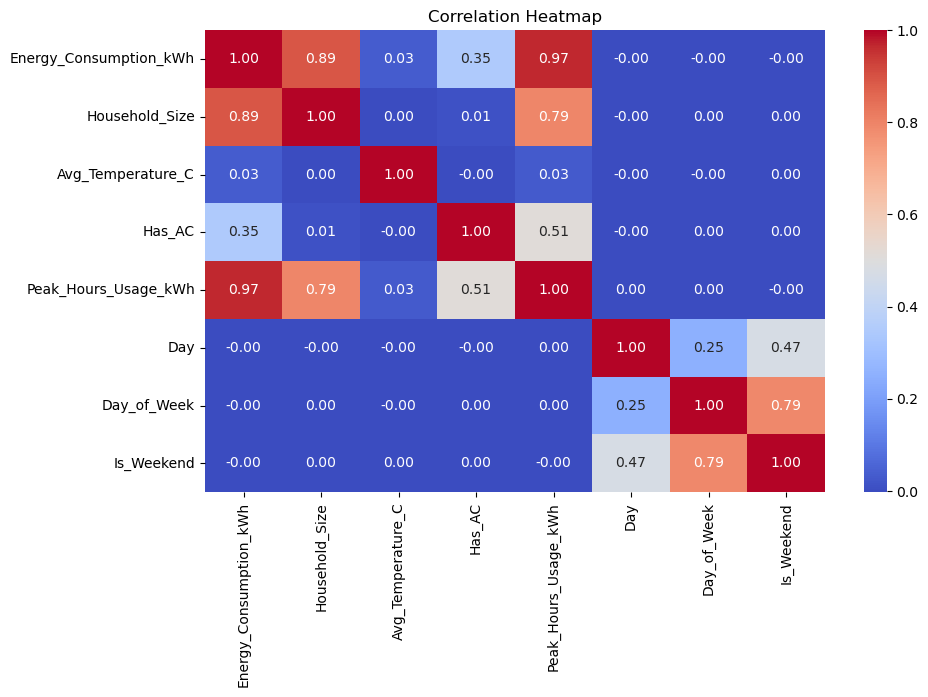

In [9]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

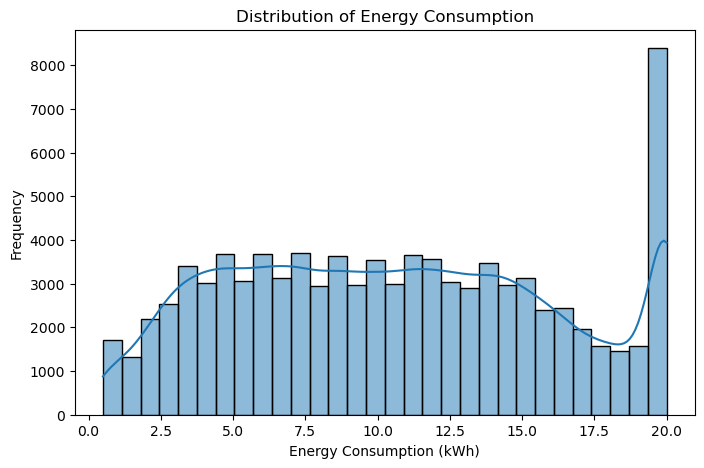

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Energy_Consumption_kWh"], bins=30, kde=True)

plt.title("Distribution of Energy Consumption")
plt.xlabel("Energy Consumption (kWh)")
plt.ylabel("Frequency")
plt.show()

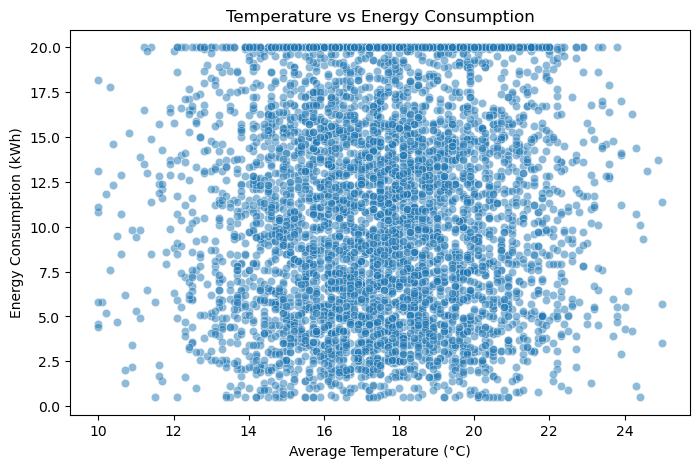

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df.sample(5000),
    x="Avg_Temperature_C",
    y="Energy_Consumption_kWh",
    alpha=0.5
)

plt.title("Temperature vs Energy Consumption")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Energy Consumption (kWh)")
plt.show()

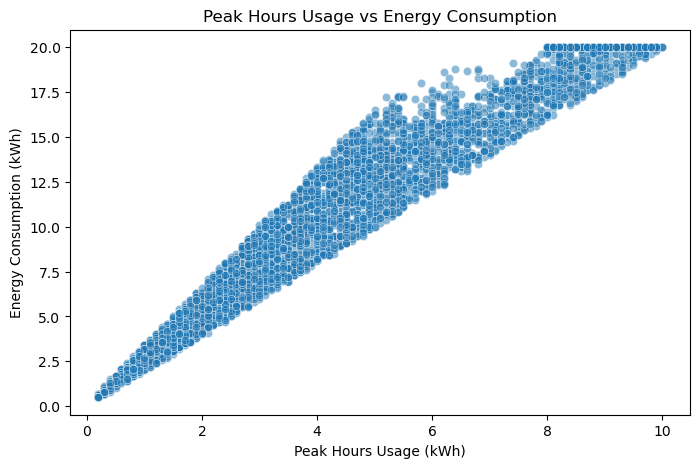

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df.sample(5000),
    x="Peak_Hours_Usage_kWh",
    y="Energy_Consumption_kWh",
    alpha=0.5
)

plt.title("Peak Hours Usage vs Energy Consumption")
plt.xlabel("Peak Hours Usage (kWh)")
plt.ylabel("Energy Consumption (kWh)")
plt.show()

# Model

In [13]:
features = [
    "Household_Size",
    "Avg_Temperature_C",
    "Has_AC",
    "Peak_Hours_Usage_kWh",
    "Day",
    "Day_of_Week",
    "Is_Weekend"
]

X = df[features]
y = df["Energy_Consumption_kWh"]

print("Features:", X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['Household_Size', 'Avg_Temperature_C', 'Has_AC', 'Peak_Hours_Usage_kWh', 'Day', 'Day_of_Week', 'Is_Weekend']
X shape: (90000, 7)
y shape: (90000,)


In [14]:
# train test split

split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 72000
Testing samples: 18000


In [15]:
# feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
# multiple linear regression model
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression
MSE : 0.6199840393691841
RMSE: 0.7873906523252509
R²  : 0.9797724216118451


In [17]:
# polynomial regression model
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])

poly_model.fit(X_train, y_train)

y_pred_poly = poly_model.predict(X_test)

mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial Regression")
print("MSE :", mse_poly)
print("RMSE:", rmse_poly)
print("R²  :", r2_poly)

Polynomial Regression
MSE : 0.45853030897482866
RMSE: 0.6771486609119364
R²  : 0.9850400055821271


In [18]:
# ridge regression model
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression")
print("MSE :", mse_ridge)
print("RMSE:", rmse_ridge)
print("R²  :", r2_ridge)

Ridge Regression
MSE : 0.6199874874100084
RMSE: 0.7873928418585023
R²  : 0.9797723091161813


In [19]:
# comparing model performance
results = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "Polynomial Regression",
        "Ridge Regression"
    ],
    "MSE": [
        mse_linear,
        mse_poly,
        mse_ridge
    ],
    "RMSE": [
        rmse_linear,
        rmse_poly,
        rmse_ridge
    ],
    "R2 Score": [
        r2_linear,
        r2_poly,
        r2_ridge
    ]
})

results

,Model,MSE,RMSE,R2 Score
0,Multiple Linear Regression,0.619984,0.787391,0.979772
1,Polynomial Regression,0.458530,0.677149,0.985040
2,Ridge Regression,0.619987,0.787393,0.979772


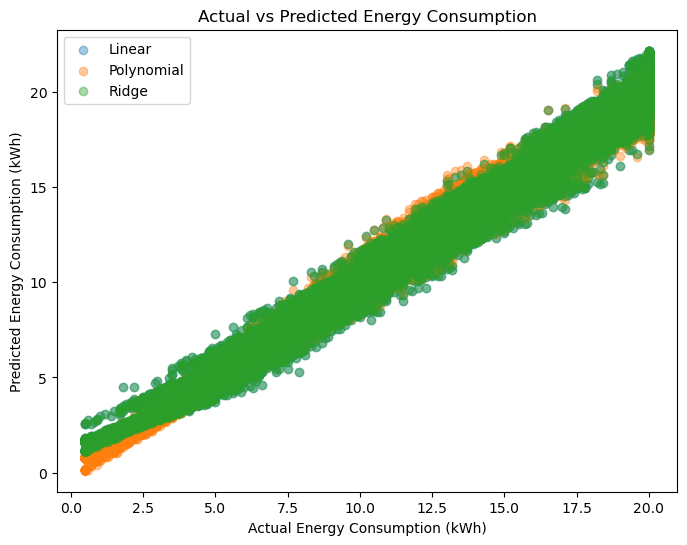

In [20]:
# actual vs predicted plot for the best model
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_linear, alpha=0.4, label="Linear")
plt.scatter(y_test, y_pred_poly, alpha=0.4, label="Polynomial")
plt.scatter(y_test, y_pred_ridge, alpha=0.4, label="Ridge")

plt.xlabel("Actual Energy Consumption (kWh)")
plt.ylabel("Predicted Energy Consumption (kWh)")
plt.title("Actual vs Predicted Energy Consumption")
plt.legend()

plt.show()

In [21]:
# 5 cross validation for the best model
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    ridge_model,
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("Cross-Validation R² Scores:")
print(cv_scores)

print("\nMean CV R²:", cv_scores.mean())

Cross-Validation R² Scores:
[0.97954037 0.97971039 0.97955653 0.97937377 0.97912953]

Mean CV R²: 0.9794621203758117


In [22]:
# grid search for ridge

param_grid = {
    "ridge__alpha": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    ridge_model,
    param_grid,
    cv=5,
    scoring="r2"
)

grid_search.fit(X_train, y_train)

print("Best Alpha:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

Best Alpha: {'ridge__alpha': 1}
Best CV R²: 0.9793632752566044


In [23]:
# final ridge model 
best_ridge = grid_search.best_estimator_

y_pred_final = best_ridge.predict(X_test)

final_mse = mean_squared_error(y_test, y_pred_final)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, y_pred_final)

print("Final Ridge Regression")
print("----------------------")
print("MSE :", final_mse)
print("RMSE:", final_rmse)
print("R²  :", final_r2)

Final Ridge Regression
----------------------
MSE : 0.6199874874100084
RMSE: 0.7873928418585023
R²  : 0.9797723091161813


In [24]:
# sample prediction
sample_household = pd.DataFrame({
    "Household_Size": [4],
    "Avg_Temperature_C": [30],
    "Has_AC": [1],
    "Peak_Hours_Usage_kWh": [4.5],
    "Day": [25],
    "Day_of_Week": [4],
    "Is_Weekend": [0]
})

prediction = best_ridge.predict(sample_household)

print(f"Predicted Energy Consumption: {prediction[0]:.2f} kWh")

Predicted Energy Consumption: 11.34 kWh


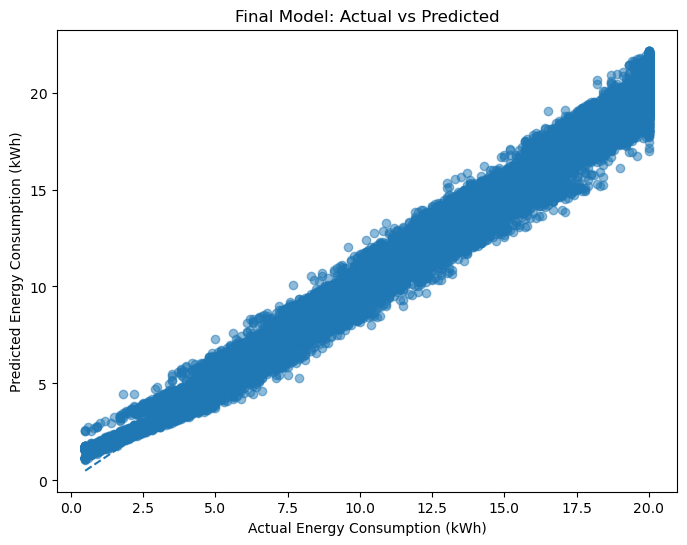

In [25]:
# final prediction plot
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_final, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Energy Consumption (kWh)")
plt.ylabel("Predicted Energy Consumption (kWh)")
plt.title("Final Model: Actual vs Predicted")

plt.show()

In [26]:
import joblib

joblib.dump(best_ridge, "energy_model.pkl")

['energy_model.pkl']

In [27]:
#final evaluation
y_pred_final = best_ridge.predict(X_test)

final_mse = mean_squared_error(y_test, y_pred_final)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, y_pred_final)

print("Final Model Performance")
print("-----------------------")
print(f"MSE  : {final_mse:.4f}")
print(f"RMSE : {final_rmse:.4f}")
print(f"R²   : {final_r2:.4f}")

Final Model Performance
-----------------------
MSE  : 0.6200
RMSE : 0.7874
R²   : 0.9798


In [ ]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'ridge__alpha': 1}
0.9793632752566044
